In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from gym import Env, spaces

class TradingEnv(Env):
    def __init__(self, data, bins_config, trading_cost=0.001, start_nav=1):
        self.data = data.reset_index(drop=True)
        self.bins_config = bins_config
        self.trading_cost = trading_cost 
        self.start_nav = start_nav # first money
        self._discretize_features()
        self.states = list(self.data['state'].values)
        self.action_space = spaces.Discrete(3) # actions: 0 = short , 1 = hold , 2 = long
        self.observation_space = spaces.MultiDiscrete([len(bins)-1 for bins in self.bins_config.values()])
        self.reset()

    def _discretize_features(self):
        feature_bins = []
        for feat, bins in self.bins_config.items():
            labels = list(range(len(bins) - 1))
            feature_bins.append(pd.cut(self.data[feat], bins=bins, labels=labels))
        self.data['state'] = list(zip(*feature_bins))

    def reset(self):
        self.current_step = 0
        self.nav = self.start_nav
        self.position = 0  # -1 : short , 0 : flat , +1 : long
        return self.states[self.current_step]

    def step(self, action):
        assert self.action_space.contains(action) # check
        prev_price = self.data.loc[self.current_step, 'Close']
        self.current_step += 1
        new_price = self.data.loc[self.current_step, 'Close']
        ret = (new_price - prev_price) / prev_price
        new_position = action - 1 # 0 1 2 -> -1 0 1
        cost = self.trading_cost * abs(new_position - self.position) # trading cost
        reward = self.position * ret - cost # r t = position t x return t − trading cost
        self.nav *= (1 + reward) # update nav
        self.position = new_position
        state = self.states[self.current_step]
        done = self.current_step >= len(self.states)-1 or self.nav <= 0 # end 
        info = {'nav': self.nav}
        return state, reward, done, info

class QAgent:
    def __init__(self, n_actions, alpha=0.1, gamma=0.99, epsilon=1.0, eps_decay=0.995, eps_min=0.01):
        self.q_table = defaultdict(lambda: np.zeros(n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.eps_decay = eps_decay
        self.eps_min = eps_min

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(self.q_table[state])) if state in self.q_table else np.random.randint(3)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state): 
        # Q(s,a) <- Q(s,a) + alpha * [r + gamma max (a prime) Q(s prime,a prime) − Q(s,a)]
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon * self.eps_decay, self.eps_min)

In [2]:
df = pd.read_csv('data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

df['Return'] = df['Close'].pct_change().fillna(0) # Return t = ( Close t - Close t-1 ) / Close t-1
# RSI 14 Days
delta = df['Close'].diff() # delta = Close t - Close t-1
up = delta.clip(lower=0)
down = -delta.clip(upper=0)
roll_up = up.rolling(window=14, min_periods=14).mean() # mean increase 14 days
roll_down = down.rolling(window=14, min_periods=14).mean() # mean decrease 14 days
rs = roll_up / (roll_down + 1e-9) # relative strength
df['RSI'] = 100 - (100 / (1 + rs))
df.fillna({'RSI' : 50}, inplace = True) # 50 for not sell not buy

bins_config = {
    'Return': np.linspace(df['Return'].min(), df['Return'].max(), 4),
    'RSI': [0, 30, 70, 100],
    'Volume': np.quantile(df['Volume'], [0, 0.33, 0.66, 1])
}

split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df = df.iloc[split_idx:].reset_index(drop=True)

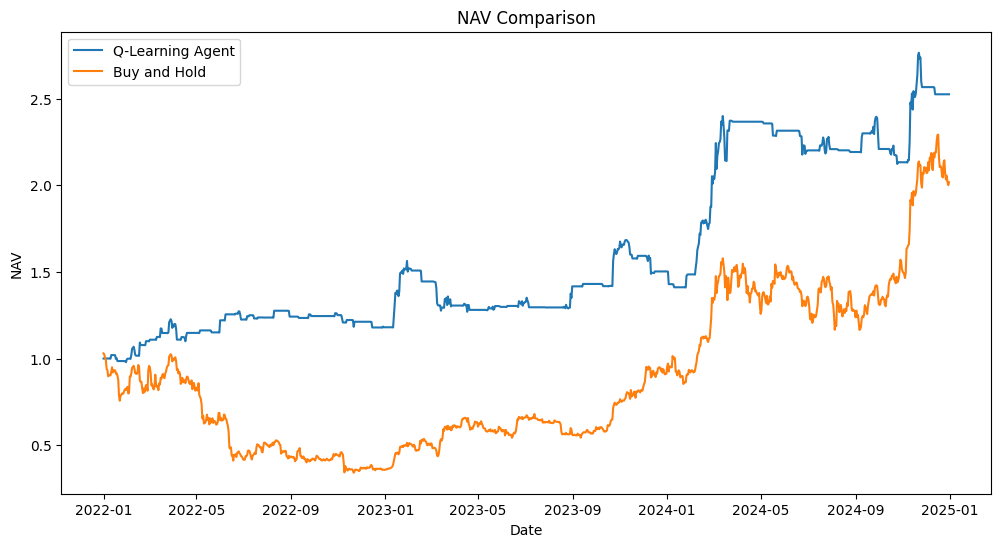

Total Return: 152.51%
Sharpe Ratio: 1.13
Max Drawdown: 29.34%
Win Rate: 14.43%


In [4]:
train_env = TradingEnv(train_df[['Close', 'Return', 'RSI', 'Volume']], bins_config)
agent = QAgent(n_actions=3)

# training
episodes = 2000 # parts
for ep in range(episodes):
    state = train_env.reset()
    done = False # end ?
    while not done :
        action = agent.select_action(state)
        next_state, reward, done, _ = train_env.step(action)
        agent.update(state, action, reward, next_state)
        state = next_state
    agent.decay_epsilon() # epsilon update

test_env = TradingEnv(test_df[['Close', 'Return', 'RSI', 'Volume']], bins_config)
state = test_env.reset()
navs = [test_env.nav]
while True:
    action = int(np.argmax(agent.q_table[state]))
    state, reward, done, info = test_env.step(action)
    navs.append(info['nav'])
    if done :
        break

# buy and hold
bh_nav = 1 * (1 + test_df['Return']).cumprod().values # nav every day
dates = test_df['Date']

plt.figure(figsize=(12, 6))
plt.plot(dates, navs, label='Q-Learning Agent')
plt.plot(dates, bh_nav, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.title('NAV Comparison')
plt.show()

returns_agent = np.diff(navs) / navs[:-1]
total_return = navs[-1] - 1
sharpe = (np.mean(returns_agent) / (np.std(returns_agent) + 1e-9)) * np.sqrt(252)
max_dd = np.max(np.maximum.accumulate(navs) - navs)
win_rate = np.mean(returns_agent > 0)

print(f"Total Return: {total_return:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")
print(f"Win Rate: {win_rate:.2%}")
